In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Function to select columns by group ID
def select_columns_by_group(df, goId, group_id):
        # Get all columns that belong to this group
    group_columns = [col for col in df.columns if column_to_group.get(col) == group_id]
    
    # Select those columns from the main DataFrame (include geography_code too)
    selected_cols = [goId] + group_columns
    return df[selected_cols]
    
def select_columns_by_group_norm(df, goId, group_id):
    # Get all columns that belong to this group
    group_columns = [col for col in df.columns if column_to_group.get(col) == group_id]
    
    if not group_columns:
        print(f"No columns found for group {group_id}")
        return pd.DataFrame()
    
    # Select the columns we need
    selected_cols = [goId] + group_columns
    result_df = df[selected_cols].copy()
    
    # Vectorized normalization - much faster!
    row_sums = result_df[group_columns].sum(axis=1)
    result_df[group_columns] = result_df[group_columns].div(row_sums, axis=0).fillna(0)
    
    return result_df

In [ ]:
def plot_combined_detailed(group_survay_data, group_synthpop_data, group_id, graph_dir=""):
    merged_df = pd.merge(
        group_survay_data, 
        group_synthpop_data, 
        left_on=group_survay_data.columns[0], 
        right_on=group_synthpop_data.columns[0], 
        suffixes=('_survey', '_synthpop')
    )
    
    data_columns = [col for col in group_survay_data.columns if col != group_survay_data.columns[0]]
    
    # Create figure with 2 rows: first row has 2 plots, second row has 1 plot
    fig, ((ax1, ax2), (ax3, _)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Hide the fourth subplot (bottom right)
    _.set_visible(False)
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(data_columns)))
    all_survey, all_synthpop = [], []
    correlations = []
    all_differences = []
    
    # Plot 1: Combined scatter plot (top left)
    for idx, col in enumerate(data_columns):
        survey_col = f"{col}_survey"
        synthpop_col = f"{col}_synthpop"
        
        ax1.scatter(merged_df[survey_col], merged_df[synthpop_col], 
                   alpha=0.3, s=4, color=colors[idx], label=col)
        
        all_survey.extend(merged_df[survey_col].values)
        all_synthpop.extend(merged_df[synthpop_col].values)
        
        # Calculate differences for this variable
        differences = (merged_df[survey_col] - merged_df[synthpop_col]).abs()
        all_differences.extend(differences.values)
        
        # Calculate individual correlation
        corr = np.corrcoef(merged_df[survey_col], merged_df[synthpop_col])[0,1]
        correlations.append((col, corr))
    
    # Combined correlation
    combined_corr = np.corrcoef(all_survey, all_synthpop)[0,1]
    
    max_val = max(max(all_survey), max(all_synthpop))
    ax1.plot([0, max_val], [0, max_val], 'k--', alpha=0.8, linewidth=2)
    
    ax1.set_xlim(0, 1.0)
    ax1.set_ylim(0, 1.0)
    ax1.set_xlabel('Survey Data')
    ax1.set_ylabel('SynthPop Data')
    ax1.set_title(f'Group {group_id}: Combined Scatter\nCombined r = {combined_corr:.3f}')
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # Plot 2: Correlation bar chart (top right)
    correlations.sort(key=lambda x: x[1])  # Sort by correlation value
    variables = [x[0] for x in correlations]
    corr_values = [x[1] for x in correlations]
    
    bars = ax2.barh(variables, corr_values, color=colors[:len(variables)])
    ax2.axvline(x=combined_corr, color='red', linestyle='--', label=f'Combined r = {combined_corr:.3f}')
    ax2.set_xlabel('Correlation Coefficient')
    ax2.set_title('Individual Variable Correlations')
    ax2.legend()
    ax2.set_xlim(0, 1.0)
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Plot 3: Histogram of differences (bottom - spans both columns)
    ax3.hist(all_differences, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    ax3.axvline(np.mean(all_differences), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(all_differences):.4f}')
    ax3.axvline(np.median(all_differences), color='orange', linestyle='--', 
                linewidth=2, label=f'Median: {np.median(all_differences):.4f}')
    
    ax3.set_xlabel('Absolute Difference (|Survey - SynthPop|)')
    ax3.set_ylabel('Frequency')
    ax3.set_title(f'Distribution of Differences\n(n={len(all_differences):,} observations)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Add some statistics as text
    stats_text = f'Std Dev: {np.std(all_differences):.4f}\nMax: {np.max(all_differences):.4f}'
    ax3.text(0.95, 0.95, stats_text, transform=ax3.transAxes, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    if graph_dir != "":
        plt.savefig(graph_dir + f'Group{group_id}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return combined_corr, correlations

In [ ]:
def plot_group_comparison_merged(group_survay_data, group_synthpop_data,group_id):
    # Merge the DataFrames on their ID columns
    merged_df = pd.merge(
        group_survay_data, 
        group_synthpop_data, 
        left_on=group_survay_data.columns[0], 
        right_on=group_synthpop_data.columns[0], 
        suffixes=('_survey', '_synthpop')
    )
    
    print(f"Merged DataFrame shape: {merged_df.shape}")
    print(f"Number of matched records: {len(merged_df)}")
    
    # Get data columns (excluding ID columns)
    data_columns = [col for col in group_survay_data.columns if col != group_survay_data.columns[0]]
    
    # Create subplots
    n_cols = min(3, len(data_columns))
    n_rows = (len(data_columns) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]
    
    for idx, col in enumerate(data_columns):
        if idx < len(axes):
            ax = axes[idx]
            
            survey_col = f"{col}_survey"
            synthpop_col = f"{col}_synthpop"
            
            # Scatter plot with matched data
            scatter = ax.scatter(merged_df[survey_col], merged_df[synthpop_col], 
                               alpha=0.4, s=2)
            
            # Perfect correlation line
            max_val = max(merged_df[survey_col].max(), merged_df[synthpop_col].max())
            ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.8, linewidth=1)
            
            ax.set_xlabel(f'Survey: {col}')
            ax.set_ylabel(f'SynthPop: {col}')
            ax.set_title(f'{col}')
            ax.grid(True, alpha=0.3)
            
            # Calculate correlation coefficient
            correlation = np.corrcoef(merged_df[survey_col], merged_df[synthpop_col])[0,1]
            ax.text(0.05, 0.95, f'r = {correlation:.3f}', 
                   transform=ax.transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Hide unused subplots
    for idx in range(len(data_columns), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'Group {group_id}: Survey vs SynthPop (Matched Data)', fontsize=16, y=1.02)
    plt.tight_layout()

    plt.show()

In [15]:
# HR 30/10/25 Bundling plotting into function so path to data can be specified
def validation_plots(upper_folder_path):

    survey_path = os.path.join(upper_folder_path, 'data/Northern Ireland/census2021_ni_go.csv')
    synthpop_path = os.path.join(upper_folder_path, 'results/synthPopSurveyNIb.csv')
    groups_path = os.path.join(upper_folder_path, 'data/Northern Ireland/groupsNI.csv')
    graphs_path = os.path.join(upper_folder_path, 'data/Northern Ireland/graphs/')
    if not os.path.exists(graphs_path):
        os.makedirs(graphs_path)
    
    # Read the main data CSV
    dfSurvay = pd.read_csv(survey_path)
    dfSynthPop = pd.read_csv(synthpop_path)
    
    # Read the groups CSV
    groups_df = pd.read_csv(groups_path)
    column_to_group = dict(zip(groups_df['heading'], groups_df['group']))
    max_group = groups_df['group'].max()
    min_group = groups_df['group'].min()
    combined_corr0 = []
    correlations = []
    
    for group in range(min_group, max_group):
        group_survay_data = select_columns_by_group_norm(dfSurvay, dfSurvay.columns[0], group)
        group_synthpop_data = select_columns_by_group_norm(dfSynthPop, dfSynthPop.columns[0], group)
        cc, c = plot_combined_detailed(group_survay_data, group_synthpop_data, group, graphs_path)
        combined_corr0.append(cc)

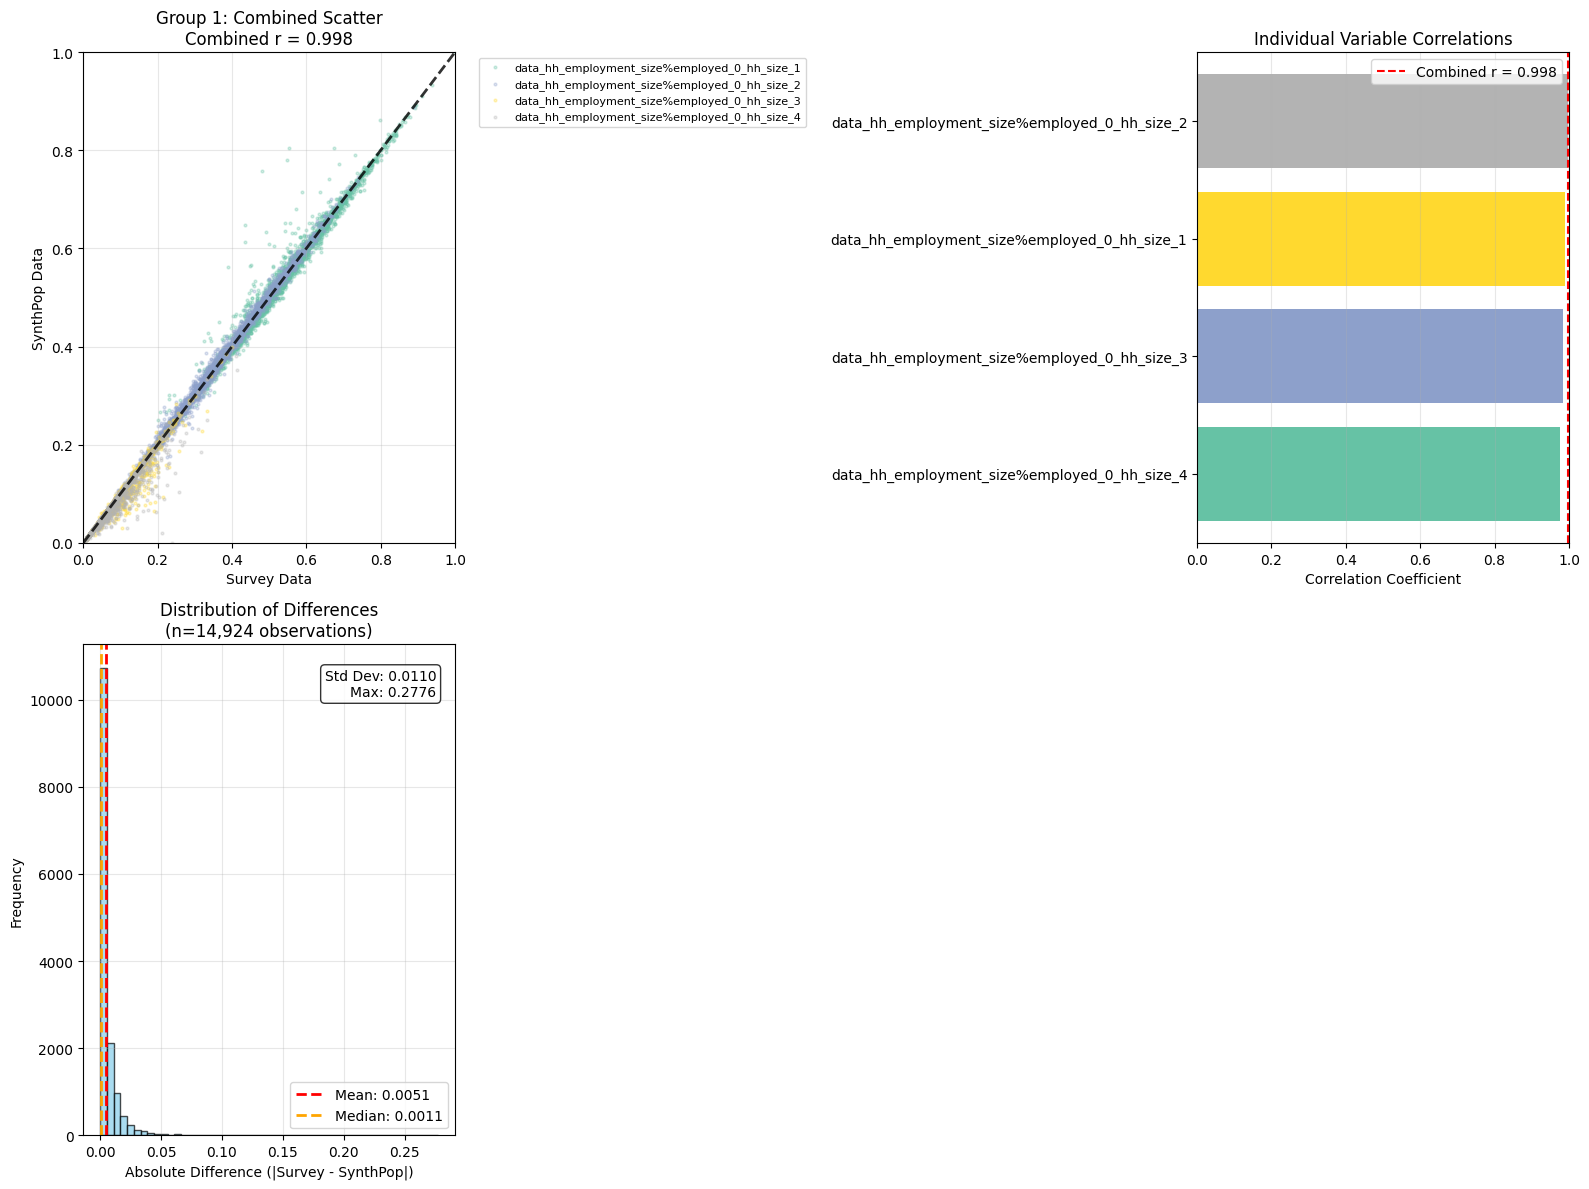

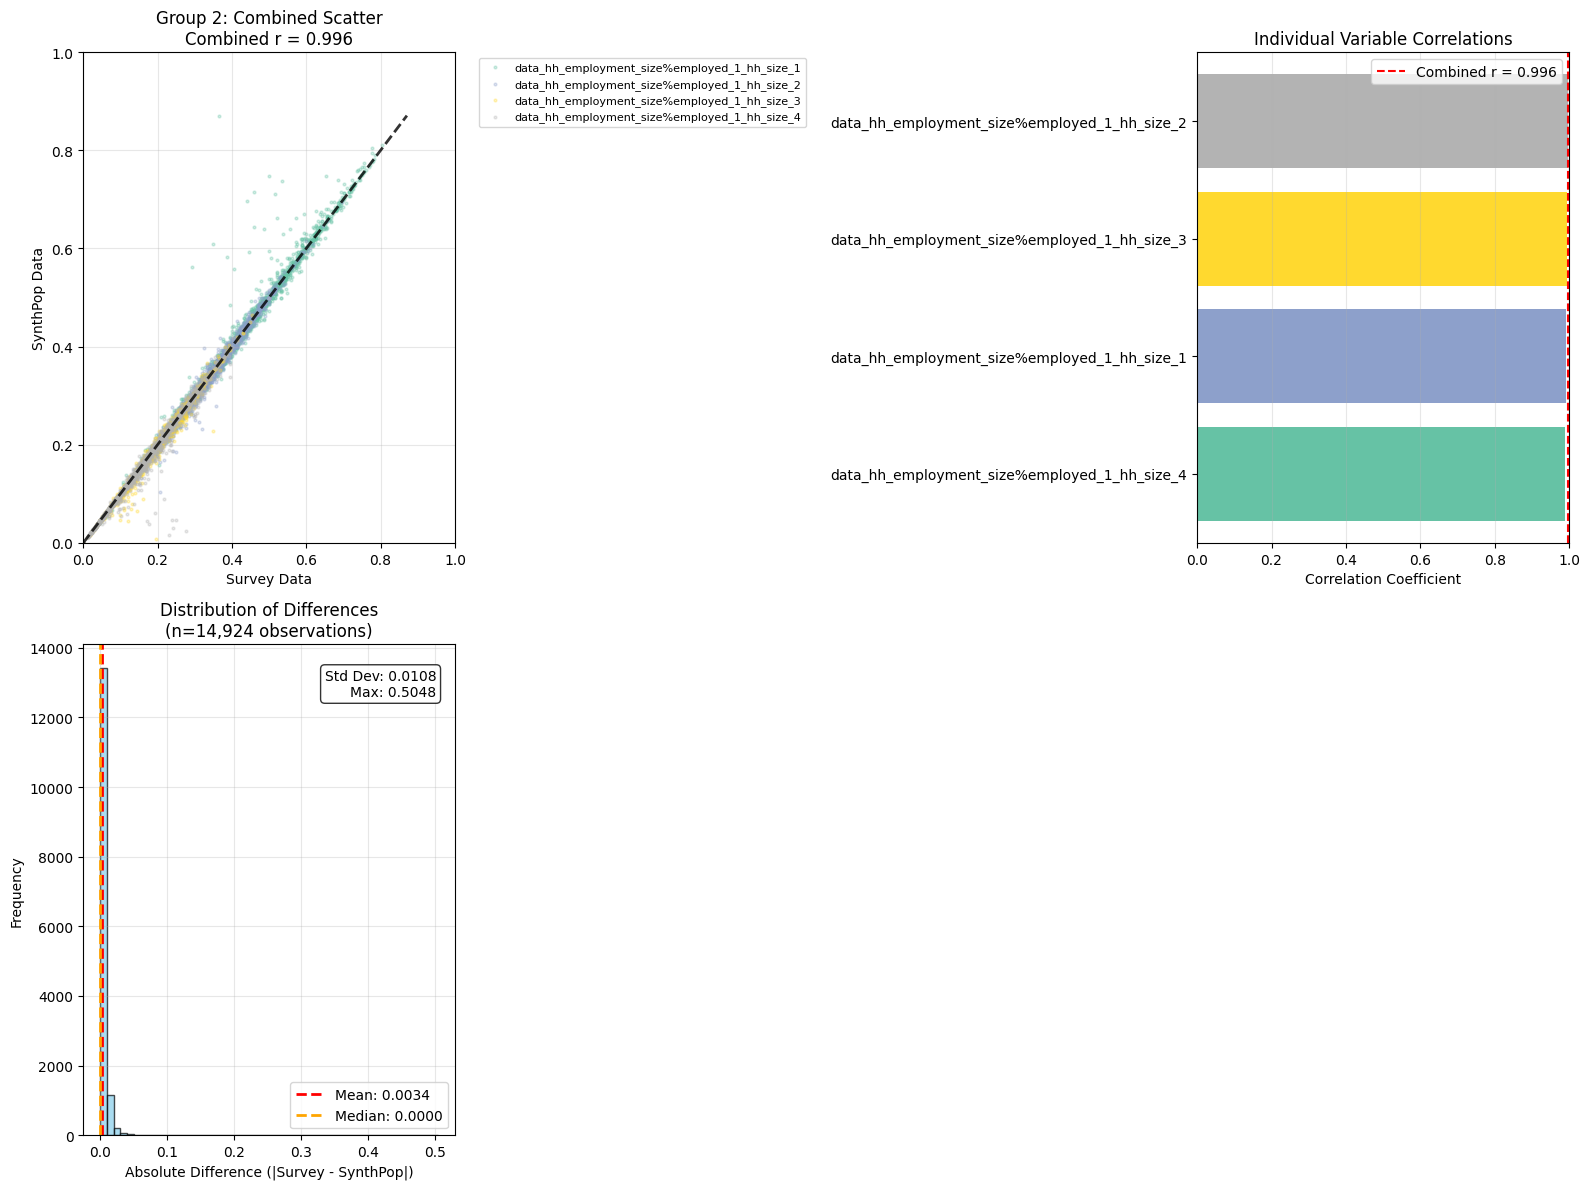

/home/prehr/miniconda3/envs/synthpop_sandbox/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


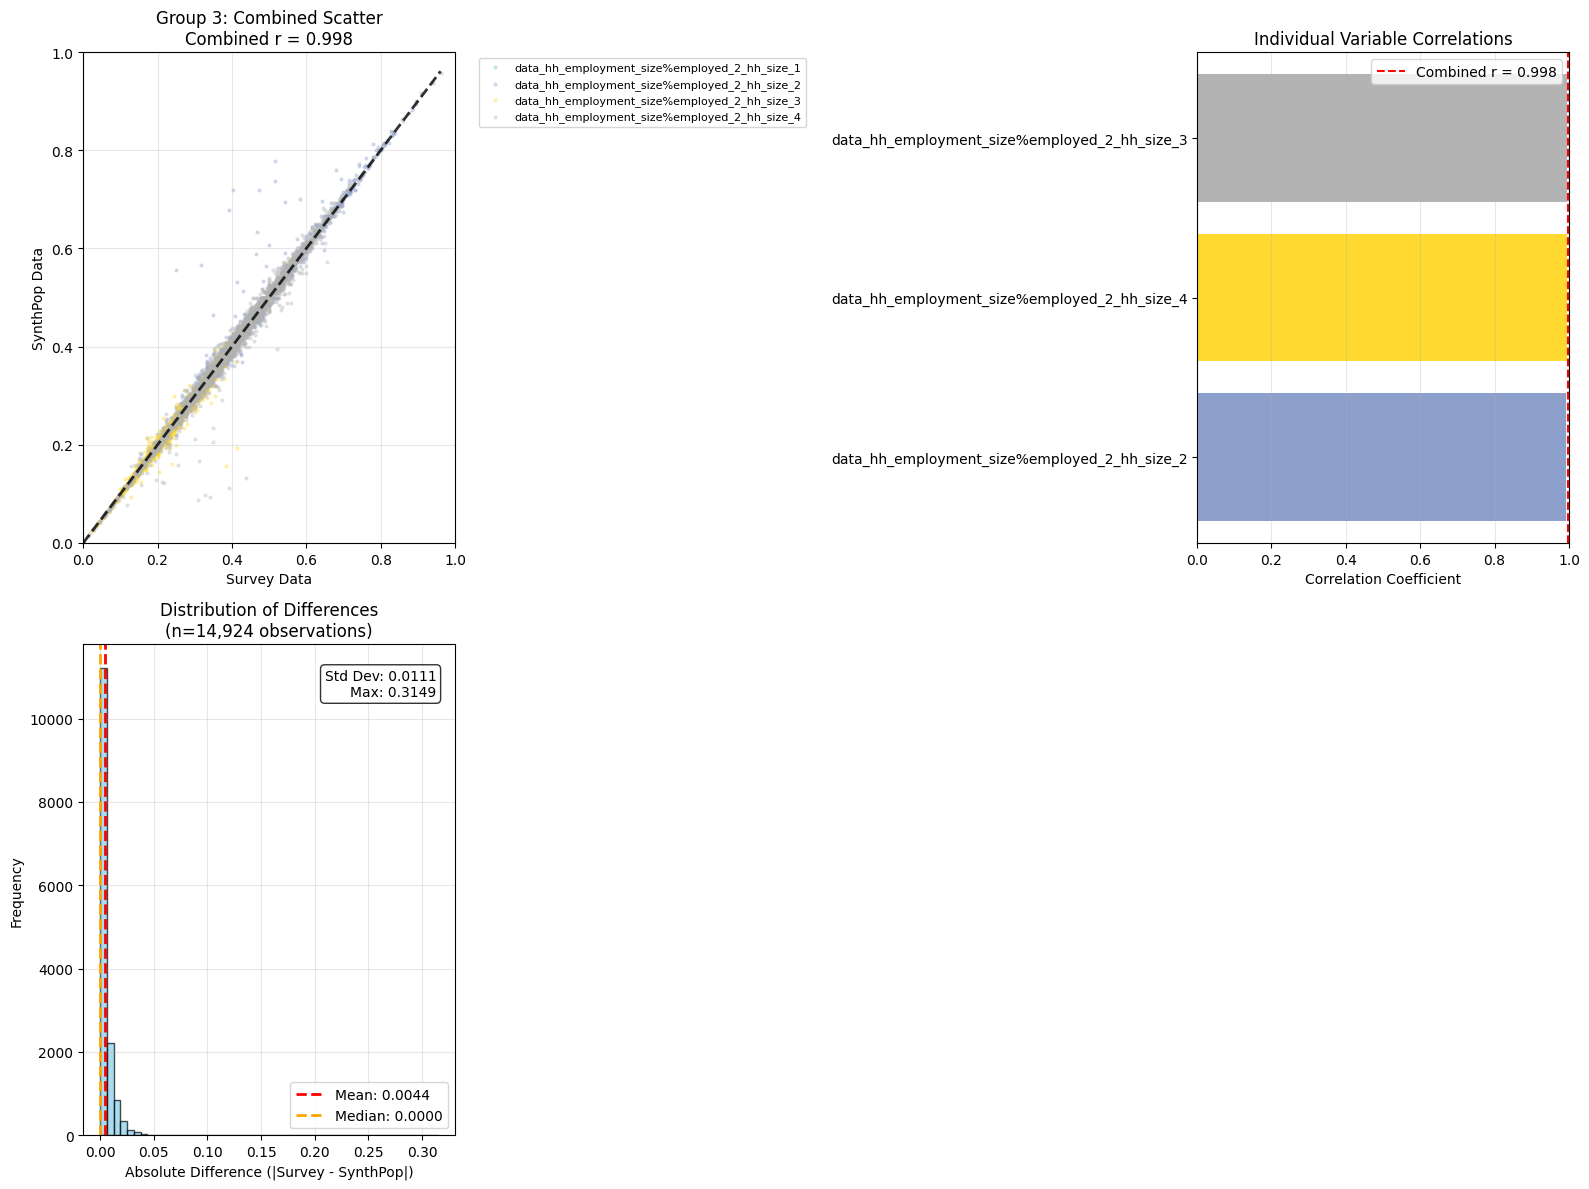

/home/prehr/miniconda3/envs/synthpop_sandbox/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


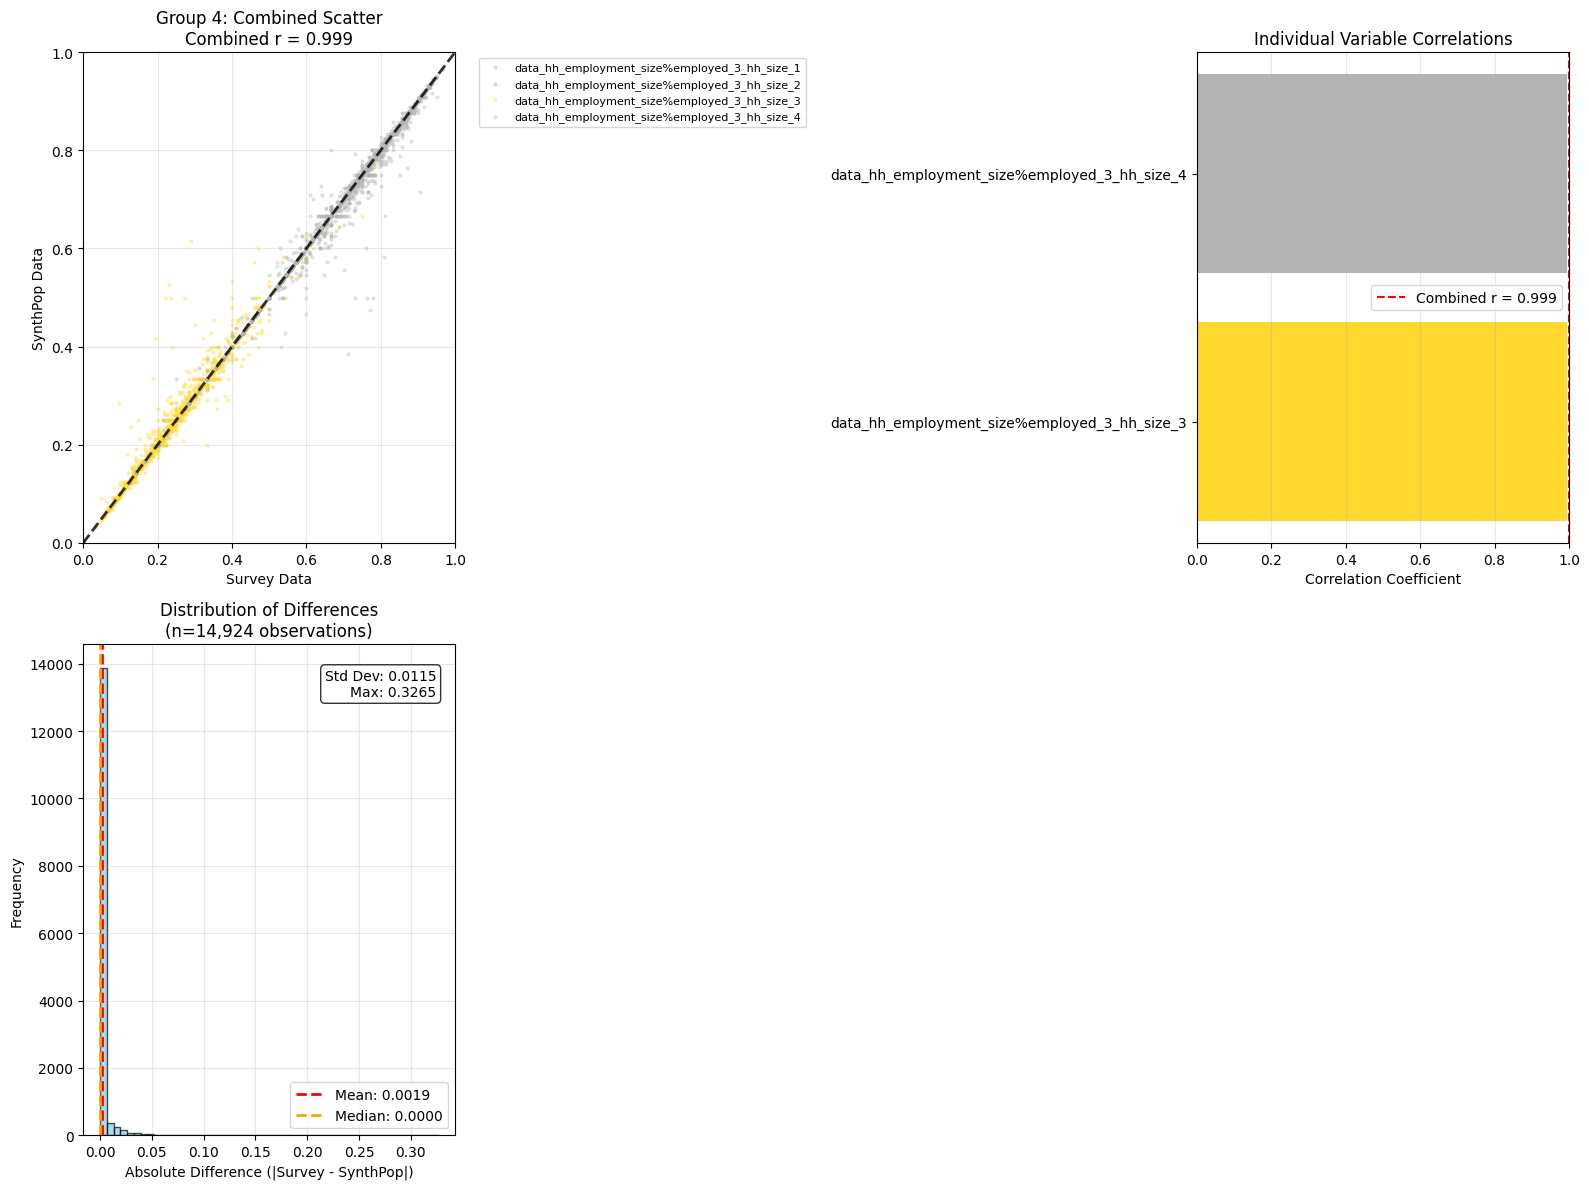

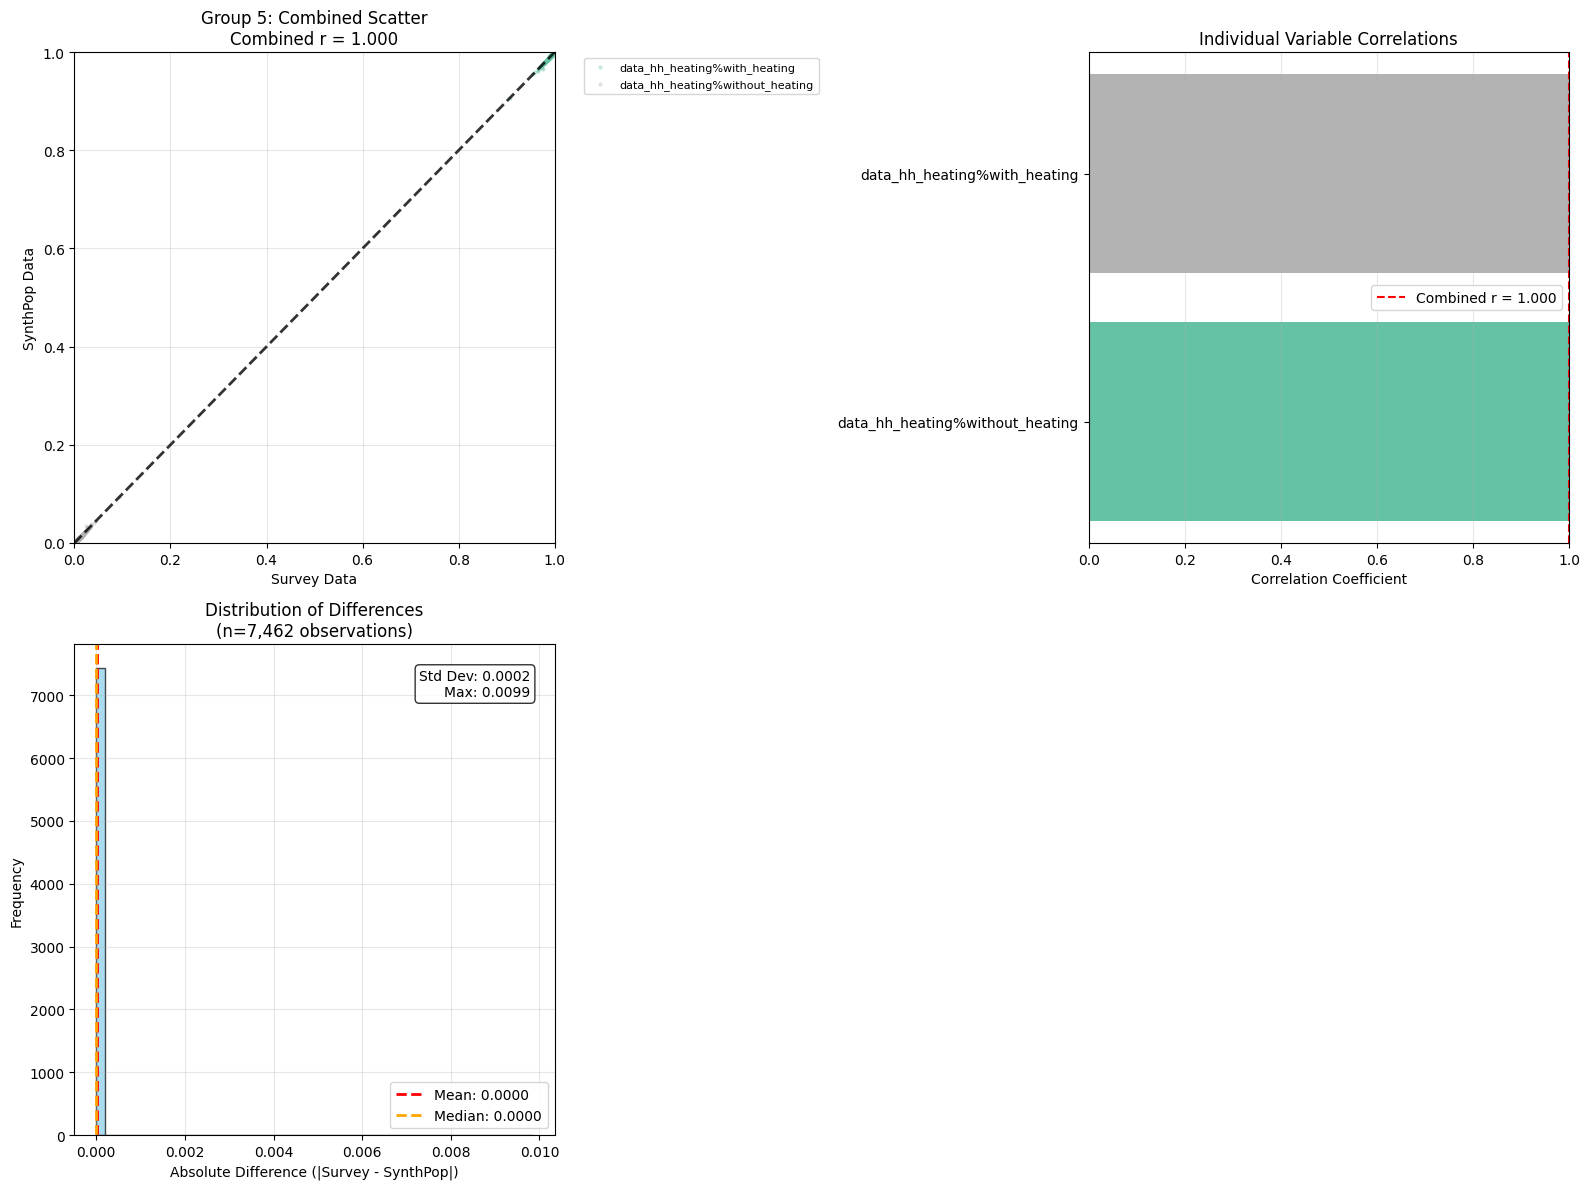

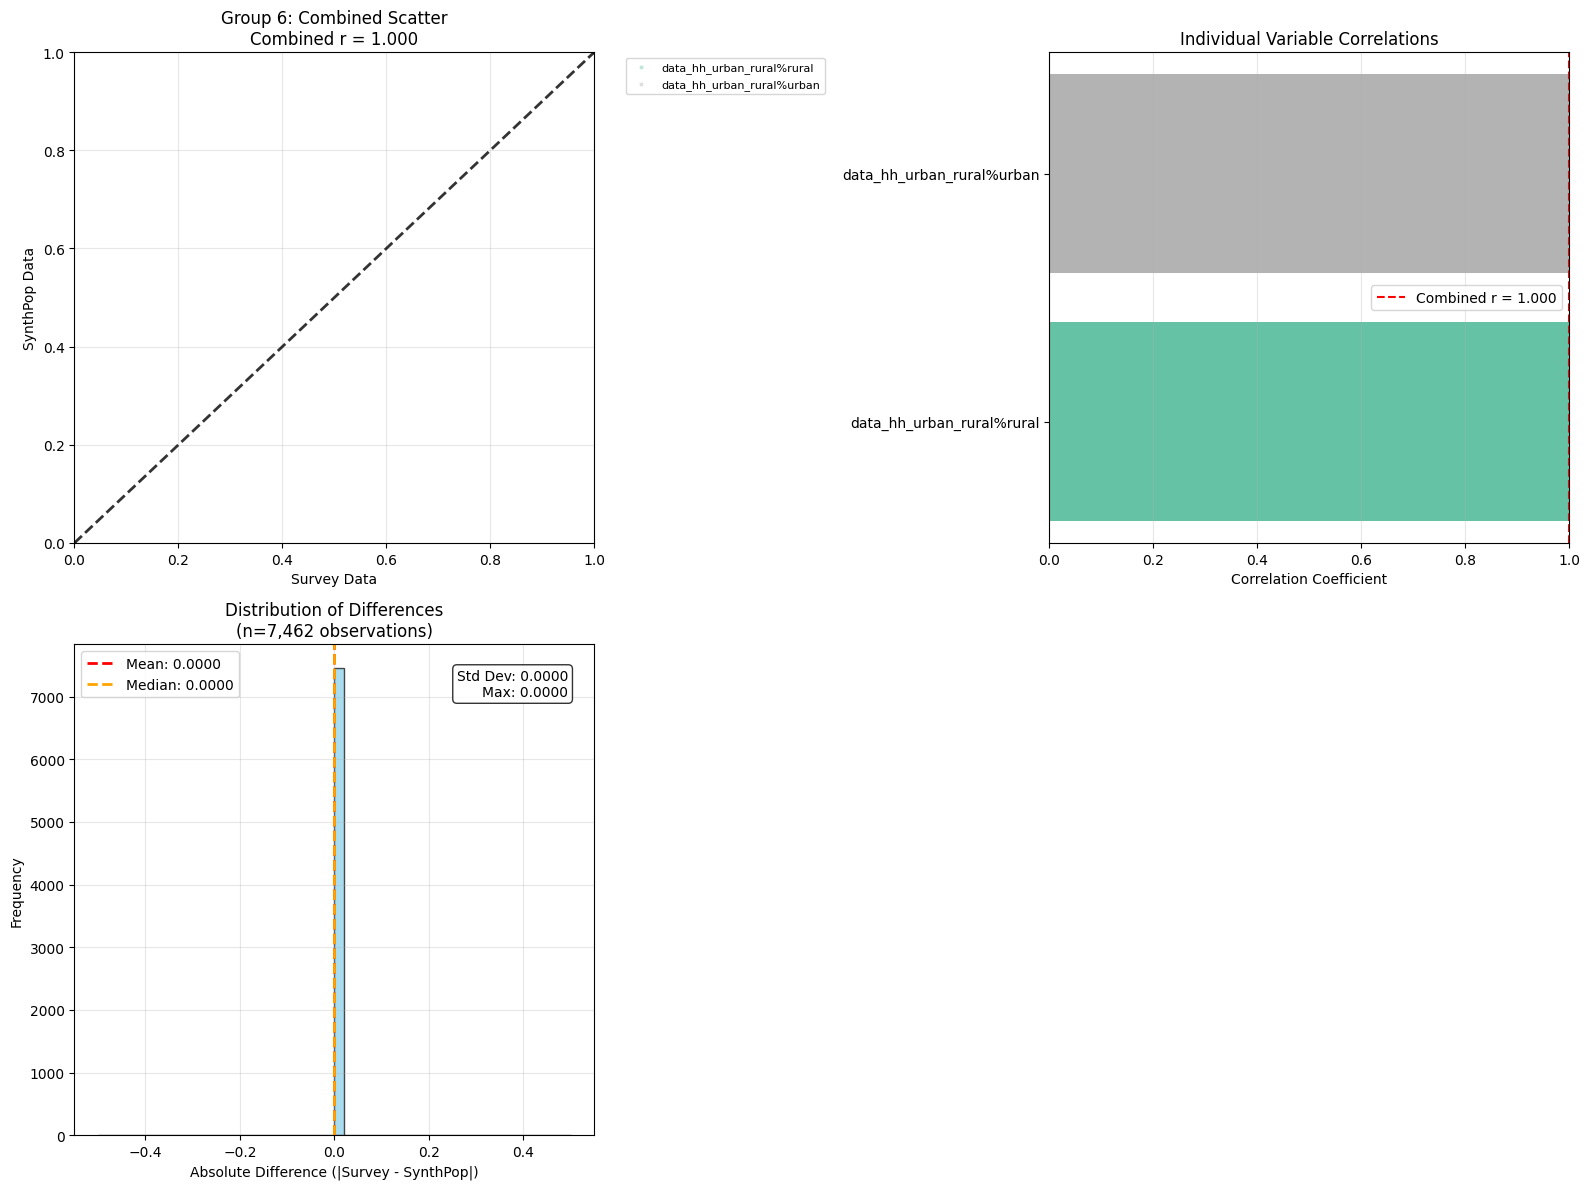

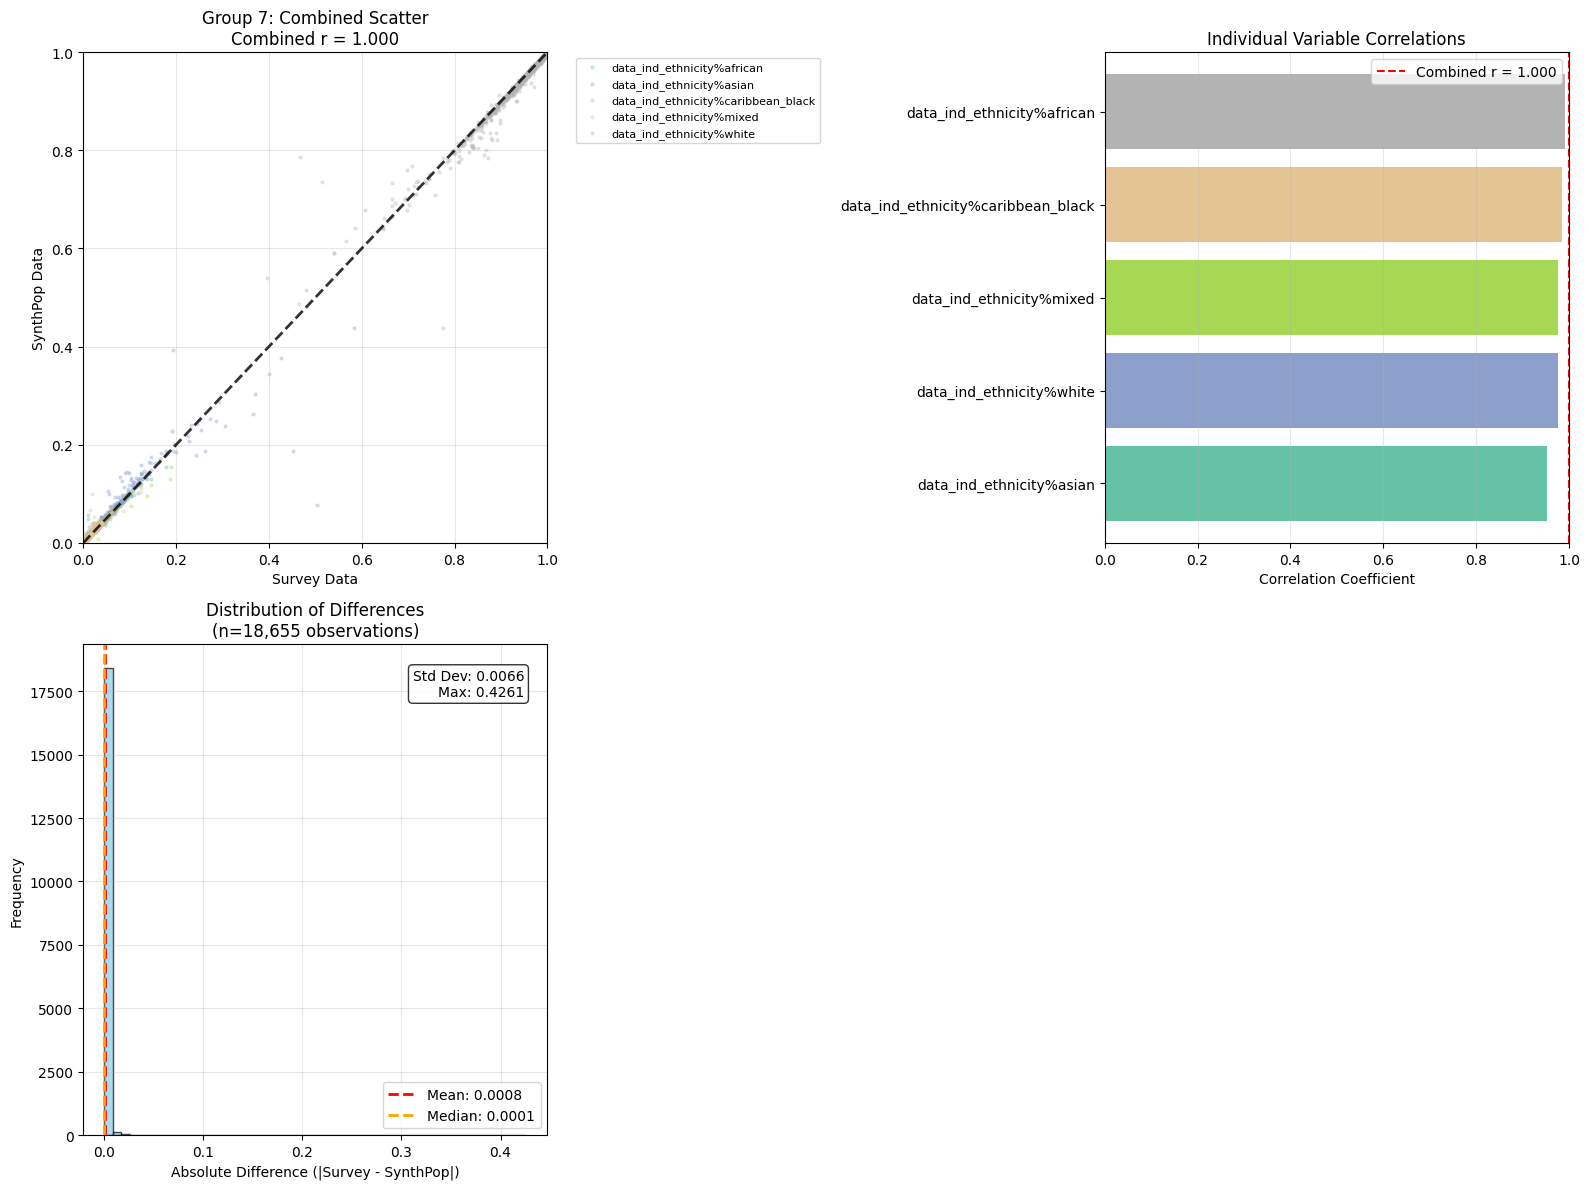

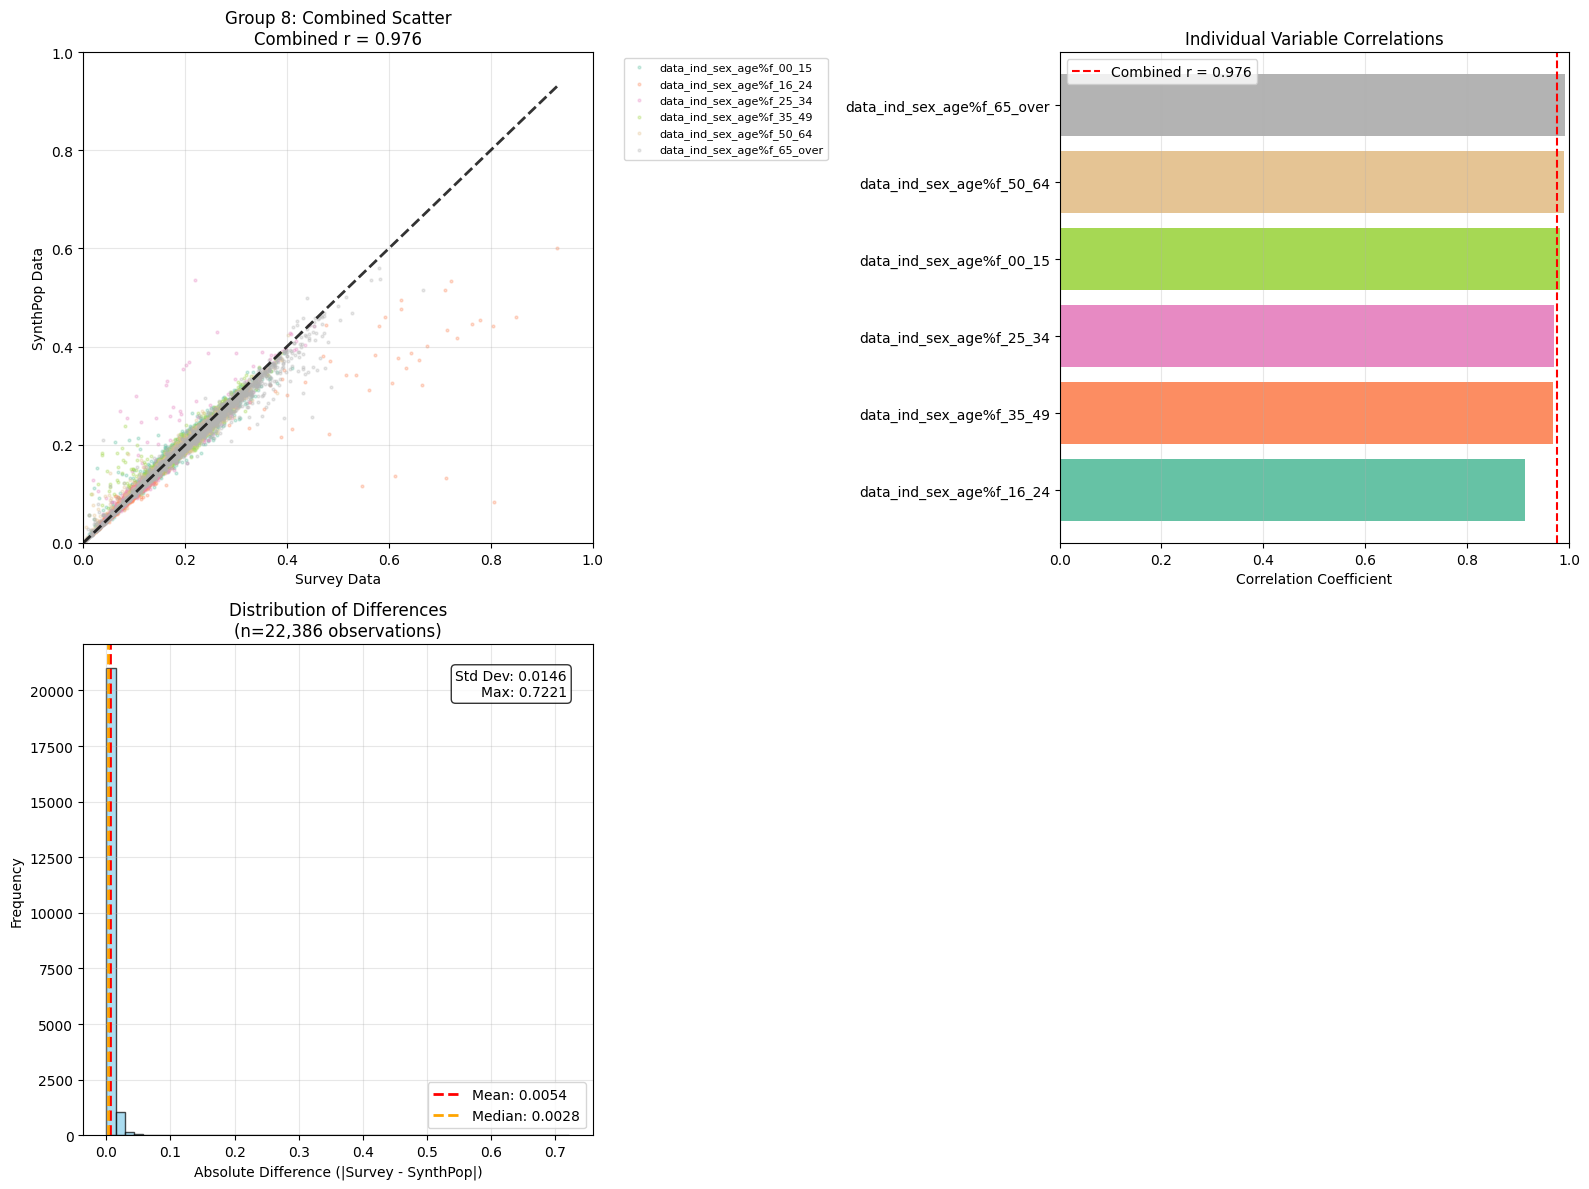

In [16]:
# HR 30/10/25 Run validation plots per indicator; manually get local path to stop errors
# _path = os.path.expanduser('~')
_path = os.path.abspath('')
validation_plots(_path)